In [1]:
import pandas as pd
import numpy as np
import os
import csv
import ast
from collections import Counter
import geopandas as gpd
import h5py
from datetime import datetime, timedelta
##### for plotting ###
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

In [2]:
df_policies_2020 = pd.read_csv("../data/OxCGRT_USA_differentiated_withnotes_2020.csv", low_memory=False)
df_policies_2021 = pd.read_csv("../data/OxCGRT_USA_differentiated_withnotes_2021.csv", low_memory=False)

In [5]:
df_policies_2021.columns

Index(['CountryName', 'CountryCode', 'RegionName', 'RegionCode',
       'Jurisdiction', 'Date', 'C1E_School closing', 'C1E_Flag',
       'C1NV_School closing', 'C1NV_Flag',
       ...
       'ContainmentHealthIndex_NonVaccinated',
       'ContainmentHealthIndex_NonVaccinated_ForDisplay',
       'ContainmentHealthIndex_Vaccinated',
       'ContainmentHealthIndex_Vaccinated_ForDisplay',
       'ContainmentHealthIndex_SimpleAverage',
       'ContainmentHealthIndex_SimpleAverage_ForDisplay',
       'ContainmentHealthIndex_WeightedAverage',
       'ContainmentHealthIndex_WeightedAverage_ForDisplay',
       'EconomicSupportIndex', 'EconomicSupportIndex_ForDisplay'],
      dtype='object', length=160)

In [9]:
df_poli_indx_20 = df_policies_2020[['RegionName', 'Date', 'StringencyIndex_WeightedAverage']]
df_poli_index_ca_20 = df_poli_indx_20[df_poli_indx_20['RegionName']=='California']
df_poli_index_nc_20 = df_poli_indx_20[df_poli_indx_20['RegionName']=='North Carolina']
df_poli_indx_21 = df_policies_2021[['RegionName', 'Date', 'StringencyIndex_WeightedAverage']]
df_poli_index_ca_21 = df_poli_indx_21[df_poli_indx_21['RegionName']=='California']
df_poli_index_nc_21 = df_poli_indx_21[df_poli_indx_21['RegionName']=='North Carolina']

In [10]:
df_poli_ca = pd.concat([df_poli_index_ca_20, df_poli_index_ca_21])
df_poli_nc = pd.concat([df_poli_index_nc_20, df_poli_index_nc_21])
len(df_poli_ca) ### start from sunday and it is a daily data we have to convert it to weekly data with the average of the week
df_poli_ca['Date'] = pd.to_datetime(df_poli_ca['Date'],format='%Y%m%d')
df_poli_nc['Date'] = pd.to_datetime(df_poli_nc['Date'],format='%Y%m%d')
start_date = '2020-02-24' ### monday
end_date = '2021-02-14' ### monday

In [12]:
mask_ca = (df_poli_ca['Date'] >= start_date) & (df_poli_ca['Date'] <= end_date)
mask_nc = (df_poli_nc['Date'] >= start_date) & (df_poli_nc['Date'] <= end_date)
df_poli_ca_s = df_poli_ca.loc[mask_ca]
df_poli_nc_s = df_poli_nc.loc[mask_nc]
df_poli_ca_s.set_index('Date', inplace=True)
df_poli_nc_s.set_index('Date', inplace=True)

In [13]:
stringency_7_ca = df_poli_ca_s['StringencyIndex_WeightedAverage'].rolling(window=7).mean()
stringency_7_nc = df_poli_nc_s['StringencyIndex_WeightedAverage'].rolling(window=7).mean()
stringency_wk_ca = pd.DataFrame(stringency_7_ca[stringency_7_ca.index.weekday == 6])
stringency_wk_nc = pd.DataFrame(stringency_7_nc[stringency_7_nc.index.weekday == 6])

Text(0.5, 1.0, 'North Carolina')

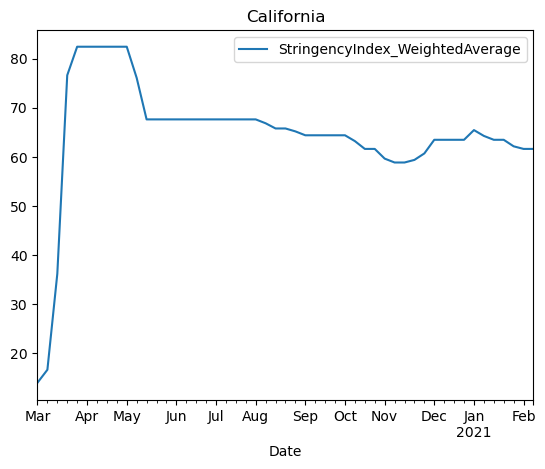

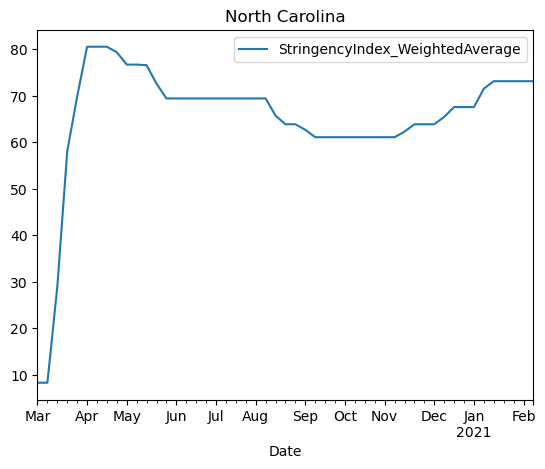

In [19]:
stringency_wk_ca.plot()
plt.title('California')
stringency_wk_nc.plot()
plt.title('North Carolina')

In [21]:
stringency_wk_nc.to_csv('stringency_wk_nc.csv')
stringency_wk_ca.to_csv('stringency_wk_ca.csv')